<a href="https://colab.research.google.com/github/MohammedZ666/NeuralNetInterpolation/blob/main/VGGNet_Interpolation_ImageNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries
This code was based on the [Transfer Learning for Computer Vision Tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) by [Sasank Chilamkurthy](https://chsasank.com/), released under a BSD license.

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt

from PIL import Image
from tempfile import TemporaryDirectory
from torch.utils.data import Dataset
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import torch.nn.functional as F
from datasets import load_dataset


def train_model(model, device, criterion, optimizer, scheduler, dloaders, save_dir, num_epochs=25, skip_val=False):
    best_acc = 0.0
    pbar = tqdm(range(num_epochs))

    for epoch in pbar:
        results = {"train": None, "val": None}

        for phase in ['train', 'val']:
            if skip_val and phase == 'val':
              torch.save(model.state_dict(), save_dir)
              continue
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            results[phase] = f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}'

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), save_dir)

        pbar.set_description(f'{results["train"]} {results["val"]}')

    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(torch.load(save_dir, weights_only=True))
    return model

def visualize_model(model, dloaders, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dloaders['val']):

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

def evaluate(model, device, dataloader):
    model.eval()
    running_corrects = 0.0
    printed = False

    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        if not printed:
            print(f"Input Shape: {inputs.shape}")
            printed = True

        with torch.no_grad():
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

        running_corrects += torch.sum(preds == labels.data)

        # store for f1 score
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = running_corrects.double() / dataset_sizes["val"]

    f1 = f1_score(all_labels, all_preds, average="macro")

    return {"Accuracy":acc.item(),
            "F1Score": f1}

def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated



cudnn.benchmark = True
plt.ion()   # interactive mode

# Initializing ImageNet Dataset



In [ ]:
default_size = 224
interp_size = default_size * 2
batch_size = 32

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(default_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(default_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


data_transforms_interp = {
    'train': transforms.Compose([
        transforms.Resize(512),
        transforms.CenterCrop(interp_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(512),
        transforms.CenterCrop(interp_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

class TransformDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

        # TinyImageNet class names
        self.classes = dataset.features['label'].names

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        img = item['image'].convert("RGB")   # PIL image
        label = item['label']

        if self.transform:
            img = self.transform(img)

        return img, label

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

base_url = "https://huggingface.co/datasets/ILSVRC/imagenet-1k/resolve/main/data"

data = {
      'train': load_dataset(
          "parquet",
          split="train",
          data_files=[
              f"{base_url}/train-0000{x}-of-00294.parquet" if x < 10
              else f"{base_url}/train-000{x}-of-00294.parquet"
              for x in range(1)
              ]
          ),
      'val': load_dataset(
          "parquet",
          split="train",
          data_files=[
              f"{base_url}/validation-0000{x}-of-00014.parquet" if x < 10
              else f"{base_url}/validation-000{x}-of-00014.parquet"
              for x in range(14)
              ]
          ),

}

image_datasets = {x: TransformDataset(data[x], data_transforms[x])
                  for x in ['train', 'val']}

image_datasets_interp = {x: TransformDataset(data[x], data_transforms_interp[x])
                  for x in ['train', 'val']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size,
                                             shuffle=True if x=="train" else False, num_workers=0) for x in ['train', 'val']}

dataloaders_interp = {x: torch.utils.data.DataLoader(image_datasets_interp[x], batch_size=batch_size,
                                             shuffle=True if x=="train" else False, num_workers=0) for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
device = "cuda" if torch.cuda.is_available() else "cpu"

data/train-00000-of-00294.parquet:   0%|          | 0.00/505M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

data/validation-00000-of-00014.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

data/validation-00001-of-00014.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/validation-00002-of-00014.parquet:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

data/validation-00010-of-00014.parquet:   0%|          | 0.00/475M [00:00<?, ?B/s]

data/validation-00011-of-00014.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

data/validation-00012-of-00014.parquet:   0%|          | 0.00/493M [00:00<?, ?B/s]

data/validation-00013-of-00014.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

# Dataset size

In [ ]:
dataset_sizes, data['train'], data['val']

({'train': 4358, 'val': 50000},
 Dataset({
     features: ['image', 'label'],
     num_rows: 4358
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 50000
 }))

# Dataloader size

In [ ]:
for inputs, labels in dataloaders["val"]:
    dsize = inputs.element_size() * inputs.nelement()
    print(f"Batch {batch_size}, size: {dsize/1024**3:.2f} GB")
    break

for inputs, labels in dataloaders_interp["val"]:
    dsize_interp = inputs.element_size() * inputs.nelement()
    print(f"Batch {batch_size}, size: {dsize_interp/1024**3:.2f} GB")
    break

Batch 32, size: 0.02 GB
Batch 32, size: 0.07 GB


# Visualize Default Dataset

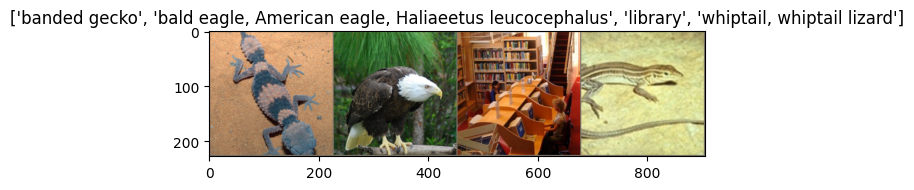

(torch.Size([32, 3, 224, 224]), torch.Size([4]))

In [ ]:
# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:4])
classes = classes[:4]

imshow(out, title=[class_names[x] for x in classes])
inputs.shape, classes.shape

# Visualize Interpolated Dataset

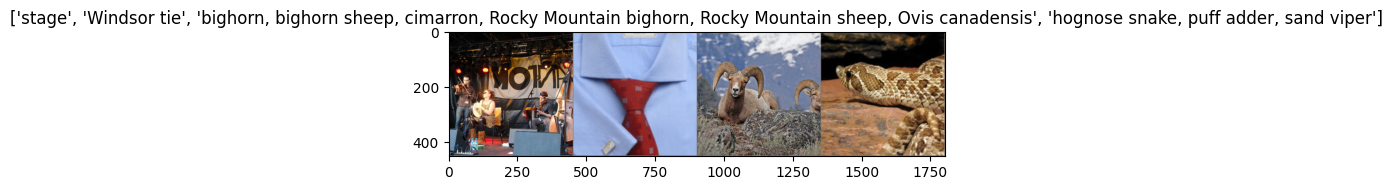

(torch.Size([32, 3, 448, 448]), torch.Size([4]))

In [ ]:
# Get a batch of training data
inputs, classes = next(iter(dataloaders_interp['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:4])
classes = classes[:4]

imshow(out, title=[class_names[x] for x in classes])
inputs.shape, classes.shape

# Interpolation Method

In [ ]:
def get_leaf_modules(model):
    leaf_modules = []

    for module in model.modules():  # recursive
        # A leaf has no children
        if len(list(module.children())) == 0:
            leaf_modules.append(module)

    return leaf_modules

def interp(model_interp, factor, f_attenuation=True):
  sqrt_factor = int(np.sqrt(factor))
  model_interp = copy.deepcopy(model_interp)
  named_modules = get_leaf_modules(model_interp)
  linear_shape = (512, 7, 7)
  for index, module in enumerate(named_modules):
    if isinstance(module, torch.nn.Conv2d):
      name = "Conv2d"
      print("Before", name, module.weight.shape, module.padding)
      orishape = module.weight.shape[-2:]
      size = [sqrt_factor*x-1 for x in orishape]
      k = np.prod(orishape)/np.prod(size) if f_attenuation else 1
      interp_weight = F.interpolate(module.weight,
                                    size=size, mode="bicubic") * k
      module.weight.data = interp_weight
      module.padding = (size[0]//2, size[1]//2)
      print("After", name, module.weight.shape, module.padding)
    elif isinstance(module, torch.nn.Linear) and isinstance(model_interp.avgpool, torch.nn.Identity):
      name = "Linear"
      prev_module = None
      for i in range(index-1, -1, -1):
        has_params = sum(p.numel() for p in named_modules[i].parameters()) > 0
        if has_params:
          prev_module = named_modules[i]
          break
      print("Before", name, module.weight.shape)
      if not isinstance(prev_module, torch.nn.Linear):
        # Standalone or begining of fc
        k = 1/factor if f_attenuation else 1
        shape = module.weight.shape
        interp_weight = module.weight.reshape(shape[0], *linear_shape)
        interp_weight = F.interpolate(interp_weight,
                                      size=[sqrt_factor *  x for x in linear_shape[-2:]],
                                      mode="bicubic") * k
        interp_weight = interp_weight.reshape(shape[0], -1)
        module.weight.data = interp_weight.reshape(shape[0], -1)
      print("After", name, module.weight.shape)
  return model_interp

# Model Declaration

In [ ]:
save_dir = "vgg16.pt"

model_ft = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# num_ftrs = model_ft.fc.in_features
# model_ft.fc = nn.Linear(num_ftrs, len(class_names))
model_ft = model_ft.to(device)
model_ft_interp = interp(model_ft, 4) # Internally copied inside `interp()`
model_ft_interp_faulty = interp(model_ft, 4, f_attenuation=False)
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 153MB/s]


Before Conv2d torch.Size([64, 3, 3, 3]) (1, 1)
After Conv2d torch.Size([64, 3, 5, 5]) (2, 2)
Before Conv2d torch.Size([64, 64, 3, 3]) (1, 1)
After Conv2d torch.Size([64, 64, 5, 5]) (2, 2)
Before Conv2d torch.Size([128, 64, 3, 3]) (1, 1)
After Conv2d torch.Size([128, 64, 5, 5]) (2, 2)
Before Conv2d torch.Size([128, 128, 3, 3]) (1, 1)
After Conv2d torch.Size([128, 128, 5, 5]) (2, 2)
Before Conv2d torch.Size([256, 128, 3, 3]) (1, 1)
After Conv2d torch.Size([256, 128, 5, 5]) (2, 2)
Before Conv2d torch.Size([256, 256, 3, 3]) (1, 1)
After Conv2d torch.Size([256, 256, 5, 5]) (2, 2)
Before Conv2d torch.Size([256, 256, 3, 3]) (1, 1)
After Conv2d torch.Size([256, 256, 5, 5]) (2, 2)
Before Conv2d torch.Size([512, 256, 3, 3]) (1, 1)
After Conv2d torch.Size([512, 256, 5, 5]) (2, 2)
Before Conv2d torch.Size([512, 512, 3, 3]) (1, 1)
After Conv2d torch.Size([512, 512, 5, 5]) (2, 2)
Before Conv2d torch.Size([512, 512, 3, 3]) (1, 1)
After Conv2d torch.Size([512, 512, 5, 5]) (2, 2)
Before Conv2d torch.Si

# Fine-tuning the Default Model

In [ ]:
from pynvml import *
import threading
import time
import gc

model_ft_interp = model_ft_interp.to("cpu")
model_ft_interp_faulty = model_ft_interp_faulty.to("cpu")

print(f"Verifying model_ft_interp device: {next(model_ft_interp.parameters()).device}")
print(f"Verifying model_ft_interp_faulty device: {next(model_ft_interp_faulty.parameters()).device}")

gc.collect()

torch.cuda.empty_cache()


nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)


epoch_avg_mem = []
epoch_peak_mem = []

def monitor():
    while running:
        mem = nvmlDeviceGetMemoryInfo(handle).used
        samples.append(mem)
        time.sleep(0.01)

for epoch in tqdm(range(7)):

    samples = []

    running = True

    thread = threading.Thread(target=monitor)
    thread.start()

    train_model(
        model_ft,
        device,
        criterion,
        optimizer_ft,
        exp_lr_scheduler,
        dataloaders,
        save_dir,
        num_epochs=1,
        skip_val=True
    )

    torch.cuda.synchronize()

    running = False
    thread.join()


    avg_mem = np.mean(samples)
    peak_mem = np.max(samples)

    if epoch > 1:
      epoch_avg_mem.append(avg_mem)
      epoch_peak_mem.append(peak_mem)

    print(f"Epoch {epoch+1}")
    print(f"  Avg : {avg_mem / 1024**3:.3f} GB")
    print(f"  Peak: {peak_mem / 1024**3:.3f} GB")


print("\n=== Overall Statistics ===")

print(
    f"Average Memory Mean: "
    f"{np.mean(epoch_avg_mem)/1024**3:.3f} GB"
)

print(
    f"Average Memory Std : "
    f"{np.std(epoch_avg_mem)/1024**3:.3f} GB"
)

print(
    f"Peak Memory Mean   : "
    f"{np.mean(epoch_peak_mem)/1024**3:.3f} GB"
)

print(
    f"Peak Memory Std    : "
    f"{np.std(epoch_peak_mem)/1024**3:.3f} GB"
)

Verifying model_ft_interp device: cpu
Verifying model_ft_interp_faulty device: cpu


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Best val Acc: 0.000000
Epoch 1
  Avg : 7.059 GB
  Peak: 8.983 GB


  0%|          | 0/1 [00:00<?, ?it/s]

...

Best val Acc: 0.000000
Epoch 5
  Avg : 7.164 GB
  Peak: 7.164 GB


  0%|          | 0/1 [00:00<?, ?it/s]

Best val Acc: 0.000000
Epoch 6
  Avg : 7.164 GB
  Peak: 7.164 GB


  0%|          | 0/1 [00:00<?, ?it/s]

Best val Acc: 0.000000
Epoch 7
  Avg : 7.164 GB
  Peak: 7.164 GB

=== Overall Statistics ===
Average Memory Mean: 7.164 GB
Average Memory Std : 0.000 GB
Peak Memory Mean   : 7.164 GB
Peak Memory Std    : 0.000 GB


# Fine-tuning the Interpolated Model

In [ ]:
from pynvml import *
import threading
import time
import gc

model_ft = model_ft.to("cpu")
model_ft_interp_faulty = model_ft_interp_faulty.to("cpu")

print(f"Verifying model_ft device: {next(model_ft.parameters()).device}")
print(f"Verifying model_ft_interp_faulty device: {next(model_ft_interp_faulty.parameters()).device}")

gc.collect()
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft_interp.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

torch.cuda.empty_cache()


nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)


epoch_avg_mem = []
epoch_peak_mem = []

def monitor():
    while running:
        mem = nvmlDeviceGetMemoryInfo(handle).used
        samples.append(mem)
        time.sleep(0.01)

for epoch in tqdm(range(7)):

    samples = []

    running = True

    thread = threading.Thread(target=monitor)
    thread.start()


    train_model(
        model_ft_interp,
        device,
        criterion,
        optimizer_ft,
        exp_lr_scheduler,
        dataloaders_interp,
        save_dir,
        num_epochs=1,
        skip_val=True
    )

    torch.cuda.synchronize()

    running = False
    thread.join()


    avg_mem = np.mean(samples)
    peak_mem = np.max(samples)

    if epoch > 1:
      epoch_avg_mem.append(avg_mem)
      epoch_peak_mem.append(peak_mem)

    print(f"Epoch {epoch+1}")
    print(f"  Avg : {avg_mem / 1024**3:.3f} GB")
    print(f"  Peak: {peak_mem / 1024**3:.3f} GB")


print("\n=== Overall Statistics ===")

print(
    f"Average Memory Mean: "
    f"{np.mean(epoch_avg_mem)/1024**3:.3f} GB"
)

print(
    f"Average Memory Std : "
    f"{np.std(epoch_avg_mem)/1024**3:.3f} GB"
)

print(
    f"Peak Memory Mean   : "
    f"{np.mean(epoch_peak_mem)/1024**3:.3f} GB"
)

print(
    f"Peak Memory Std    : "
    f"{np.std(epoch_peak_mem)/1024**3:.3f} GB"
)

Verifying model_ft device: cpu
Verifying model_ft_interp_faulty device: cpu


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Best val Acc: 0.000000
Epoch 1
  Avg : 13.109 GB
  Peak: 14.422 GB


  0%|          | 0/1 [00:00<?, ?it/s]

...

Best val Acc: 0.000000
Epoch 5
  Avg : 14.149 GB
  Peak: 14.149 GB


  0%|          | 0/1 [00:00<?, ?it/s]

Best val Acc: 0.000000
Epoch 6
  Avg : 14.149 GB
  Peak: 14.149 GB


  0%|          | 0/1 [00:00<?, ?it/s]

Best val Acc: 0.000000
Epoch 7
  Avg : 14.149 GB
  Peak: 14.149 GB

=== Overall Statistics ===
Average Memory Mean: 14.149 GB
Average Memory Std : 0.000 GB
Peak Memory Mean   : 14.149 GB
Peak Memory Std    : 0.000 GB


# Model Evaluation w AdaptiveAvgPool

In [ ]:
print(f"Base: {evaluate(model_ft, device, dataloaders["val"])}")
print(f"Interp: {evaluate(model_ft_interp, device, dataloaders_interp["val"])}")
print(f"Faulty interp: {evaluate(model_ft_interp_faulty, device, dataloaders_interp["val"])}")

  0%|          | 0/1563 [00:00<?, ?it/s]

Input Shape: torch.Size([32, 3, 224, 224])
Base: {'Accuracy': 0.71582, 'F1Score': 0.7115395781050938}


  0%|          | 0/1563 [00:00<?, ?it/s]

Input Shape: torch.Size([32, 3, 448, 448])
Interp: {'Accuracy': 0.66166, 'F1Score': 0.6577214442978572}


  0%|          | 0/1563 [00:00<?, ?it/s]

Input Shape: torch.Size([32, 3, 448, 448])
Faulty interp: {'Accuracy': 0.14066, 'F1Score': 0.1538066867130303}


 # Model Evaluation w/o AdaptiveAvgPool

In [ ]:
model_ft.avgpool = torch.nn.Identity()
model_ft_interp = interp(model_ft, 4) # Internally copied inside `interp()`
model_ft_interp_faulty = interp(model_ft, 4, f_attenuation=False)
print(f"Base: {evaluate(model_ft, device, dataloaders["val"])}")
print(f"Interp: {evaluate(model_ft_interp, device, dataloaders_interp["val"])}")
print(f"Faulty interp: {evaluate(model_ft_interp_faulty, device, dataloaders_interp["val"])}")

Before Conv2d torch.Size([64, 3, 3, 3]) (1, 1)
After Conv2d torch.Size([64, 3, 5, 5]) (2, 2)
Before Conv2d torch.Size([64, 64, 3, 3]) (1, 1)
After Conv2d torch.Size([64, 64, 5, 5]) (2, 2)
Before Conv2d torch.Size([128, 64, 3, 3]) (1, 1)
After Conv2d torch.Size([128, 64, 5, 5]) (2, 2)
Before Conv2d torch.Size([128, 128, 3, 3]) (1, 1)
After Conv2d torch.Size([128, 128, 5, 5]) (2, 2)
Before Conv2d torch.Size([256, 128, 3, 3]) (1, 1)
After Conv2d torch.Size([256, 128, 5, 5]) (2, 2)
Before Conv2d torch.Size([256, 256, 3, 3]) (1, 1)
After Conv2d torch.Size([256, 256, 5, 5]) (2, 2)
Before Conv2d torch.Size([256, 256, 3, 3]) (1, 1)
After Conv2d torch.Size([256, 256, 5, 5]) (2, 2)
Before Conv2d torch.Size([512, 256, 3, 3]) (1, 1)
After Conv2d torch.Size([512, 256, 5, 5]) (2, 2)
Before Conv2d torch.Size([512, 512, 3, 3]) (1, 1)
After Conv2d torch.Size([512, 512, 5, 5]) (2, 2)
Before Conv2d torch.Size([512, 512, 3, 3]) (1, 1)
After Conv2d torch.Size([512, 512, 5, 5]) (2, 2)
Before Conv2d torch.Si

  0%|          | 0/1563 [00:00<?, ?it/s]

Input Shape: torch.Size([32, 3, 224, 224])
Base: {'Accuracy': 0.71582, 'F1Score': 0.7115395781050938}


  0%|          | 0/1563 [00:00<?, ?it/s]

Input Shape: torch.Size([32, 3, 448, 448])
Interp: {'Accuracy': 0.66134, 'F1Score': 0.6573105822962162}


  0%|          | 0/1563 [00:00<?, ?it/s]

Input Shape: torch.Size([32, 3, 448, 448])
Faulty interp: {'Accuracy': 0.14122, 'F1Score': 0.15452306457168924}


# Visualize the Dataset

In [ ]:
visualize_model(model_ft, dataloaders)